# 12.4.2 双组分反应与模式证据

## 学习目标与先修知识

检查均匀态和模态（mode）条件，分辨机制图案与数值伪影。

先修：12.4.1 一维扩散与步长；4.3 局部稳定；3.2 矩阵（matrix）特征值（eigenvalue）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两个反应物在均匀状态（state）下稳定，却可能在扩散速度不同的空间中出现非均匀模式。看到条纹能否立即称为图灵失稳（Turing instability）？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先代入 a=.1、b=.9，手算均匀平衡（equilibrium） u*=1、v*=.9。

In [2]:
print('u*=a+b=1，v*=b/(a+b)^2=0.9；均匀态扩散项为0。')

u*=a+b=1，v*=b/(a+b)^2=0.9；均匀态扩散项为0。


## 模型假设

一维周期网格64点、间距1；使用无量纲化（nondimensionalization）的 Schnakenberg 教学动力学：$u,v,a,b$ 均为按参考尺度表示的纯数，反应项分别为 $a-u+u^2v$、$b-u^2v$。反应时间系数满足 $[\gamma]=1/T$，在所选时间单位中数值取1；扩散系数（diffusion coefficient） $D_u,D_v$ 的单位仍为格长²/T，均非负。初态是均匀态的小扰动，固定种子。

## 数学解释与推导

完整方程为 $\partial_tu=\gamma(a-u+u^2v)+D_u\partial_{xx}u$、$\partial_tv=\gamma(b-u^2v)+D_v\partial_{xx}v$；本节代码以 $[\gamma]=1/T$、数值 $\gamma=1$ 计算。均匀平衡 $(u^*,v^*)=(a+b,b/(a+b)^2)$。下述反应 Jacobian $J$ 写在所选时间单位中的数值，$J=\begin{pmatrix}-1+2u^*v^*&u^{*2}\\-2u^*v^*&-u^{*2}\end{pmatrix}$；本例 $\operatorname{tr}J=-0.2<0$（单位 1/T）、$\det J=1>0$（单位 1/T²），故无扩散小扰动局部衰减。离散空间模态的增长由 $J-q_m^2\operatorname{diag}(D_u,D_v)$ 的特征值决定，$q_m^2=4\sin^2(\pi m/n)/\Delta x^2$。本例 $D_u=.01,D_v=1$ 有正实部非零模态；用相同系数作对照可分开不同扩散率作用。还须细化空间、时间网格（time grid）与边界以排除数值伪模式。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def reaction_diffusion_step(u, v, a, b, du, dv, dx, dt, boundary):
    """Schnakenberg reaction plus nearest-neighbor diffusion in one dimension."""
    n = len(u)
    next_u, next_v = [], []
    for i in range(n):
        left = (i - 1) % n if boundary == 'periodic' else max(0, i - 1)
        right = (i + 1) % n if boundary == 'periodic' else min(n - 1, i + 1)
        lap_u = (u[left] - 2 * u[i] + u[right]) / dx**2
        lap_v = (v[left] - 2 * v[i] + v[right]) / dx**2
        react_u = a - u[i] + u[i]**2 * v[i]
        react_v = b - u[i]**2 * v[i]
        next_u.append(u[i] + dt * (react_u + du * lap_u))
        next_v.append(v[i] + dt * (react_v + dv * lap_v))
    return [next_u, next_v]


def reaction_diffusion_run(u, v, a, b, du, dv, dx, dt, steps, boundary):
    current_u, current_v = list(map(float, u)), list(map(float, v))
    u_history, v_history = [current_u.copy()], [current_v.copy()]
    for _ in range(steps):
        current_u, current_v = reaction_diffusion_step(
            current_u, current_v, a, b, du, dv, dx, dt, boundary)
        u_history.append(current_u.copy())
        v_history.append(current_v.copy())
    return [u_history, v_history]

## 对照实验

相同扰动比较不同与相同扩散系数；再将空间间距减半、保持物理长度和终止时间，检查粗网格末态是否稳定。

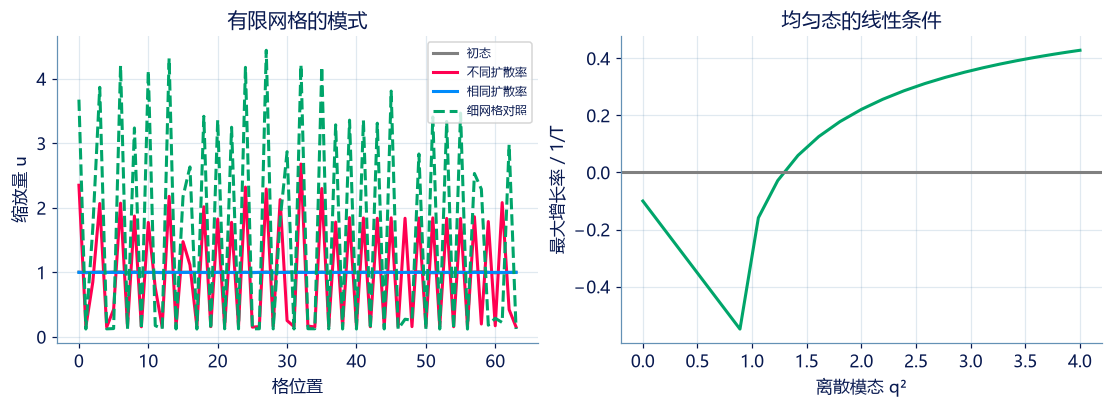

细化空间后的最大同位置差= 2.617 ；粗网格图案尚未收敛。


In [4]:
n=64;rng=np.random.default_rng(1242)
u0=(1+.005*rng.standard_normal(n)).tolist();v0=[.9]*n
u_pattern,v_pattern=reaction_diffusion_run(u0,v0,.1,.9,.01,1.,1.,.03,800,'periodic')
u_control,v_control=reaction_diffusion_run(u0,v0,.1,.9,.01,.01,1.,.03,800,'periodic')
fine_initial=np.interp(np.arange(128)/2,np.arange(n),u0,period=n).tolist()
u_fine,_=reaction_diffusion_run(fine_initial,[.9]*128,.1,.9,.01,1.,.5,.0075,3200,'periodic')
space_difference=float(np.max(np.abs(np.array(u_pattern[-1])-np.array(u_fine[-1])[::2])))
J=np.array([[.8,1.],[-1.8,-1.]])
q2=4*np.sin(np.pi*np.arange(n//2+1)/n)**2
growth=np.array([np.linalg.eigvals(J-z*np.diag([.01,1.])).real.max() for z in q2])
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(u0,label='初态',color='gray')
axes[0].plot(u_pattern[-1],label='不同扩散率',color=PINK)
axes[0].plot(u_control[-1],label='相同扩散率',color=BLUE)
axes[0].plot(np.array(u_fine[-1])[::2],label='细网格对照',color=GREEN,ls='--')
axes[0].set(xlabel='格位置',ylabel='缩放量 u',title='有限网格的模式')
axes[0].legend(fontsize=8)
axes[1].plot(q2,growth,color=GREEN);axes[1].axhline(0,color='gray')
axes[1].set(xlabel='离散模态 q²',ylabel='最大增长率 / 1/T',title='均匀态的线性条件')
plt.show()
print('细化空间后的最大同位置差=',round(space_difference,3),'；粗网格图案尚未收敛。')

## 结果解释

不同扩散率下当前网格产生非均匀模式，线性模态也有正增长；相同扩散率对照趋近均匀。但空间细化明显改变末态形状，当前图案还依赖空间网格；线性失稳分析与有限网格上的模式，需要分别解释。

### 独立核对

核对反应平衡、无扩散 Jacobian、离散正增长、时间细化及空间细化导致的不同结论。

In [5]:
np.testing.assert_allclose(reaction_diffusion_step([1.]*3,[.9]*3,.1,.9,.01,1.,1.,.03,'periodic'),[[1.]*3,[.9]*3])
assert max(np.linalg.eigvals(J).real)<0 and growth[1:].max()>0
assert np.std(u_pattern[-1])>.2 and np.std(u_control[-1])<.01
half,_=reaction_diffusion_run(u0,v0,.1,.9,.01,1.,1.,.015,1600,'periodic')
assert np.max(np.abs(np.array(half[-1])-u_pattern[-1]))<.1
assert space_difference>.5
print('均匀平衡、模态条件、时间细化及空间尚未收敛的边界均已核对。')

均匀平衡、模态条件、时间细化及空间尚未收敛的边界均已核对。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：双组分反应与扩散一步

本题使用无量纲化（nondimensionalization）的 Schnakenberg 模型（model）：u、v、a、b 是按参考尺度表示的纯数；反应项 a−u+u²v、b−u²v 乘固定的 [γ]=1/T，在所选时间数值单位中 γ 取1。两组分另按 D·离散二阶差分扩散；同步显式一步，边界 periodic 或 noflux，返回新 u 和新 v。

**函数与代码模板**

```python
def solve(
    u: list[float],
    v: list[float],
    a: float,
    b: float,
    du: float,
    dv: float,
    dx: float,
    dt: float,
    boundary: str,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `list[float]` | 第一组分当前网格，至少3格。 | 1 |
| `v` | `list[float]` | 第二组分当前网格，同长度。 | 1 |
| `a` | `float` | 第一反应输入（input），非负。 | 1 |
| `b` | `float` | 第二反应输入，非负。 | 1 |
| `du` | `float` | u 扩散系数（diffusion coefficient）。 | 格长²/T |
| `dv` | `float` | v 扩散系数。 | 格长²/T |
| `dx` | `float` | 空间间距。 | 格长 |
| `dt` | `float` | 时间步。 | T |
| `boundary` | `str` | periodic 或 noflux。 | 类别 |

**返回值**

按以下顺序返回元组：(next_u, next_v)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_u` | `list[float]` | 一步后的 u。 | 1 |
| `next_v` | `list[float]` | 一步后的 v。 | 1 |

**计算规则**

每个反应项和扩散项均只读旧 u、v；物理时间单位 T 下反应系数 [γ]=1/T，数值取1；noflux 端点采用单元中心守恒离散，越界邻居取端点。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| u | 第一组分当前网格，至少3格。 | [1.0, 1.0, 1.0] | 1 |
| v | 第二组分当前网格，同长度。 | [0.9, 0.9, 0.9] | 1 |
| a | 第一反应输入（input），非负。 | 0.1 | 1 |
| b | 第二反应输入，非负。 | 0.9 | 1 |
| du | u 扩散系数（diffusion coefficient）。 | 0.01 | 格长²/T |
| dv | v 扩散系数。 | 1 | 格长²/T |
| dx | 空间间距。 | 1 | 格长 |
| dt | 时间步。 | 0.1 | T |
| boundary | periodic 或 noflux。 | periodic | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = [1.0, 1.0, 1.0]
v = [0.9, 0.9, 0.9]
a = 0.1
b = 0.9
du = 0.01
dv = 1.0
dx = 1.0
dt = 0.1
boundary = 'periodic'

result = solve(u, v, a, b, du, dv, dx, dt, boundary)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_u | 一步后的 u。 | [1.0, 1.0, 1.0] | 1 |
| next_v | 一步后的 v。 | [0.9, 0.9, 0.9] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.0, 1.0], [0.9, 0.9, 0.9])
```

**样例解释**

均匀平衡（equilibrium） u*=a+b=1、v*=b/u*²=.9，首例一步不变；扰动和边界情形可逐项核对。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：双组分反应与扩散一步](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-reaction-diffusion-onestep)

### 第 2 题 · 单项选择题：先检查均匀平衡

本模型（model）无空间差异的平衡（equilibrium） u*=a+b、v*=b/(a+b)²。为何先核对它？

- **A.** 反应项和扩散项在该态都应为0。
- **B.** 任何可见图案都说明平衡不存在。
- **C.** 平衡自动证明图灵失稳（Turing instability）。
- **D.** 平均值相同意味着各格相同。

[作答：先检查均匀平衡](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-uniform-equilibrium)

### 第 3 题 · 单项选择题：图案与机制条件

数值模拟出现条纹，何时更有根据称为扩散驱动失稳？

- **A.** 无扩散均匀态稳定，加入扩散后有不稳定非零空间模态（mode），并通过网格与步长核验。
- **B.** 只要画面出现条纹。
- **C.** 只需扩散系数（diffusion coefficient）不同。
- **D.** 只看一次随机初态。

[作答：图案与机制条件](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-turing-evidence)

### 第 4 题 · 单项选择题：纯扩散界可直接照搬吗

纯扩散的 α≤1/2 通过后，加入反应项仍需检查什么？

- **A.** 反应动力学、正性及联合时间步误差。
- **B.** 无需任何检查。
- **C.** 只检查图像颜色。
- **D.** 把反应项当作边界。

[作答：纯扩散界可直接照搬吗](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-reaction-diffusion-step)

**进一步阅读**

[Turing 原始论文](https://doi.org/10.1098/rstb.1952.0012)讨论扩散与形态；本节是明确离散条件下的教学例，并非原论文复现。